# Exploration Notebook
Understand the data before building detection pipelines.

## 1. Setup

In [3]:
%pip install opencv-python --quiet

Note: you may need to restart the kernel to use updated packages.


In [4]:
import cv2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("../data/videos")
META_PATH = DATA_DIR / "metadata.csv"


## 2. Metadata Overview

In [5]:
df = pd.read_csv(META_PATH)
print(f"Pitches: {len(df)}")
print(f"Columns: {len(df.columns)}")
df[["pitch_type", "pitch_name", "player_name", "release_speed",
    "release_pos_x", "release_pos_z", "release_extension", "filename"]].head(10)


Pitches: 50
Columns: 121


,pitch_type,pitch_name,player_name,release_speed,release_pos_x,release_pos_z,release_extension,filename
0,SI,Sinker,"Lord, Brad",94.4,-2.40,5.28,5.5,776440_be6c4fa5_SI.mp4
1,FF,4-Seam Fastball,"Cameron, Noah",92.9,1.15,6.21,6.4,776463_a6795e29_FF.mp4
2,SL,Slider,"Soto, Gregory",86.5,2.12,5.54,6.7,776148_7f042c3a_SL.mp4
3,ST,Sweeper,"Raley, Brooks",81.8,3.14,5.30,6.5,776259_7162d643_ST.mp4
4,SI,Sinker,"Ashby, Aaron",97.2,0.20,6.53,5.5,776274_2662a7aa_SI.mp4
5,FF,4-Seam Fastball,"Brown, Hunter",97.2,-1.95,6.22,6.8,776262_97c2b3d0_FF.mp4
6,SL,Slider,"Mikolas, Miles",86.8,-1.96,6.74,6.0,776400_56e30c6e_SL.mp4
7,ST,Sweeper,"Ober, Bailey",78.4,-1.54,5.87,7.1,776324_ff20a37e_ST.mp4
8,FF,4-Seam Fastball,"Herget, Kevin",91.3,-1.96,5.91,5.6,776490_eaeffe7a_FF.mp4
9,FF,4-Seam Fastball,"Alexander, Tyler",89.9,2.51,5.50,6.4,776306_1ac078b1_FF.mp4


In [6]:
# Pitch type distribution
print("Pitch type counts:")
print(df["pitch_type"].value_counts())
print()
print("Release point stats (Statcast ground truth):")
print(df[["release_pos_x", "release_pos_z", "release_extension"]].describe().round(3))


Pitch type counts:
pitch_type
FF    14
SI    11
SL     7
ST     6
CU     4
CH     3
KC     2
FC     2
FS     1
Name: count, dtype: int64

Release point stats (Statcast ground truth):
       release_pos_x  release_pos_z  release_extension
count         50.000         50.000             50.000
mean          -0.997          5.774              6.380
std            1.859          0.528              0.501
min           -3.330          4.790              4.900
25%           -2.178          5.365              6.000
50%           -1.720          5.725              6.450
75%           -0.495          6.210              6.800
max            4.060          6.800              7.300


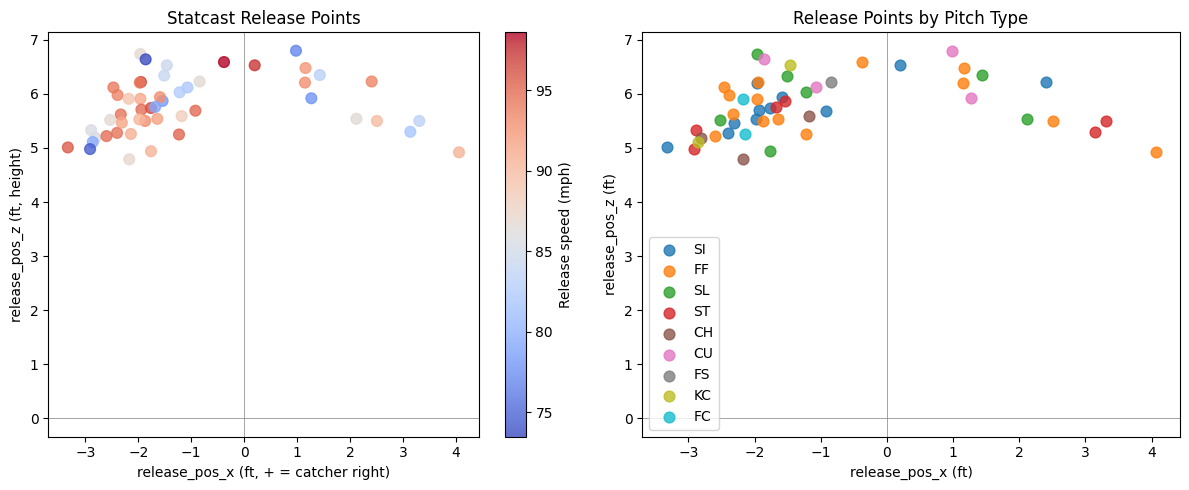

In [7]:
# Visualize release point spread from Statcast
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

scatter = axes[0].scatter(
    df["release_pos_x"], df["release_pos_z"],
    c=df["release_speed"], cmap="coolwarm", s=60, alpha=0.8
)
plt.colorbar(scatter, ax=axes[0], label="Release speed (mph)")
axes[0].set_xlabel("release_pos_x (ft, + = catcher right)")
axes[0].set_ylabel("release_pos_z (ft, height)")
axes[0].set_title("Statcast Release Points")
axes[0].axhline(0, color="gray", linewidth=0.5)
axes[0].axvline(0, color="gray", linewidth=0.5)

# Color by pitch type
pitch_types = df["pitch_type"].unique()
colors = plt.cm.tab10(np.linspace(0, 1, len(pitch_types)))
for pt, color in zip(pitch_types, colors):
    mask = df["pitch_type"] == pt
    axes[1].scatter(df[mask]["release_pos_x"], df[mask]["release_pos_z"],
                    label=pt, color=color, s=60, alpha=0.8)
axes[1].legend()
axes[1].set_xlabel("release_pos_x (ft)")
axes[1].set_ylabel("release_pos_z (ft)")
axes[1].set_title("Release Points by Pitch Type")
axes[1].axhline(0, color="gray", linewidth=0.5)
axes[1].axvline(0, color="gray", linewidth=0.5)

plt.tight_layout()
plt.show()


## 3. Video Properties

In [8]:
# Summarize all videos
rows = []
for mp4 in sorted(DATA_DIR.glob("*.mp4")):
    cap = cv2.VideoCapture(str(mp4))
    rows.append({
        "file": mp4.name,
        "fps": round(cap.get(cv2.CAP_PROP_FPS), 1),
        "width": int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)),
        "height": int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)),
        "frames": int(cap.get(cv2.CAP_PROP_FRAME_COUNT)),
        "duration_s": round(cap.get(cv2.CAP_PROP_FRAME_COUNT) / max(cap.get(cv2.CAP_PROP_FPS), 1), 2),
    })
    cap.release()

vid_df = pd.DataFrame(rows)
print(vid_df.to_string(index=False))
print()
print("FPS:", vid_df["fps"].unique())
print("Resolution:", vid_df[["width","height"]].drop_duplicates().values)
print(f"Avg duration: {vid_df['duration_s'].mean():.1f}s  |  Avg frames: {vid_df['frames'].mean():.0f}")


                  file  fps  width  height  frames  duration_s
776148_5399cd45_SL.mp4 59.4   1280     720     389        6.55
776148_7f042c3a_SL.mp4 59.8   1280     720     810       13.56
776172_6f6ed226_CU.mp4 59.7   1280     720     391        6.55
776174_14e37386_FF.mp4 59.4   1280     720     393        6.61
776204_3556e48d_KC.mp4 59.7   1280     720     662       11.09
776208_bed07cfa_ST.mp4 59.5   1280     720     394        6.62
776213_c2ad708a_ST.mp4 59.6   1280     720     464        7.79
776213_dba945a9_CH.mp4 59.5   1280     720     410        6.89
776214_e574fa80_FC.mp4 59.6   1280     720     419        7.03
776216_46c514fd_CH.mp4 59.5   1280     720     433        7.28
776244_992f73c1_SI.mp4 59.7   1280     720     437        7.32
776251_9aba59f6_CU.mp4 59.6   1280     720     440        7.38
776259_7162d643_ST.mp4 59.7   1280     720     554        9.28
776262_97c2b3d0_FF.mp4 59.7   1280     720     659       11.03
776274_2662a7aa_SI.mp4 59.6   1280     720     462     

## 4. Sample Frames from One Video

Sampling from: 776148_5399cd45_SL.mp4


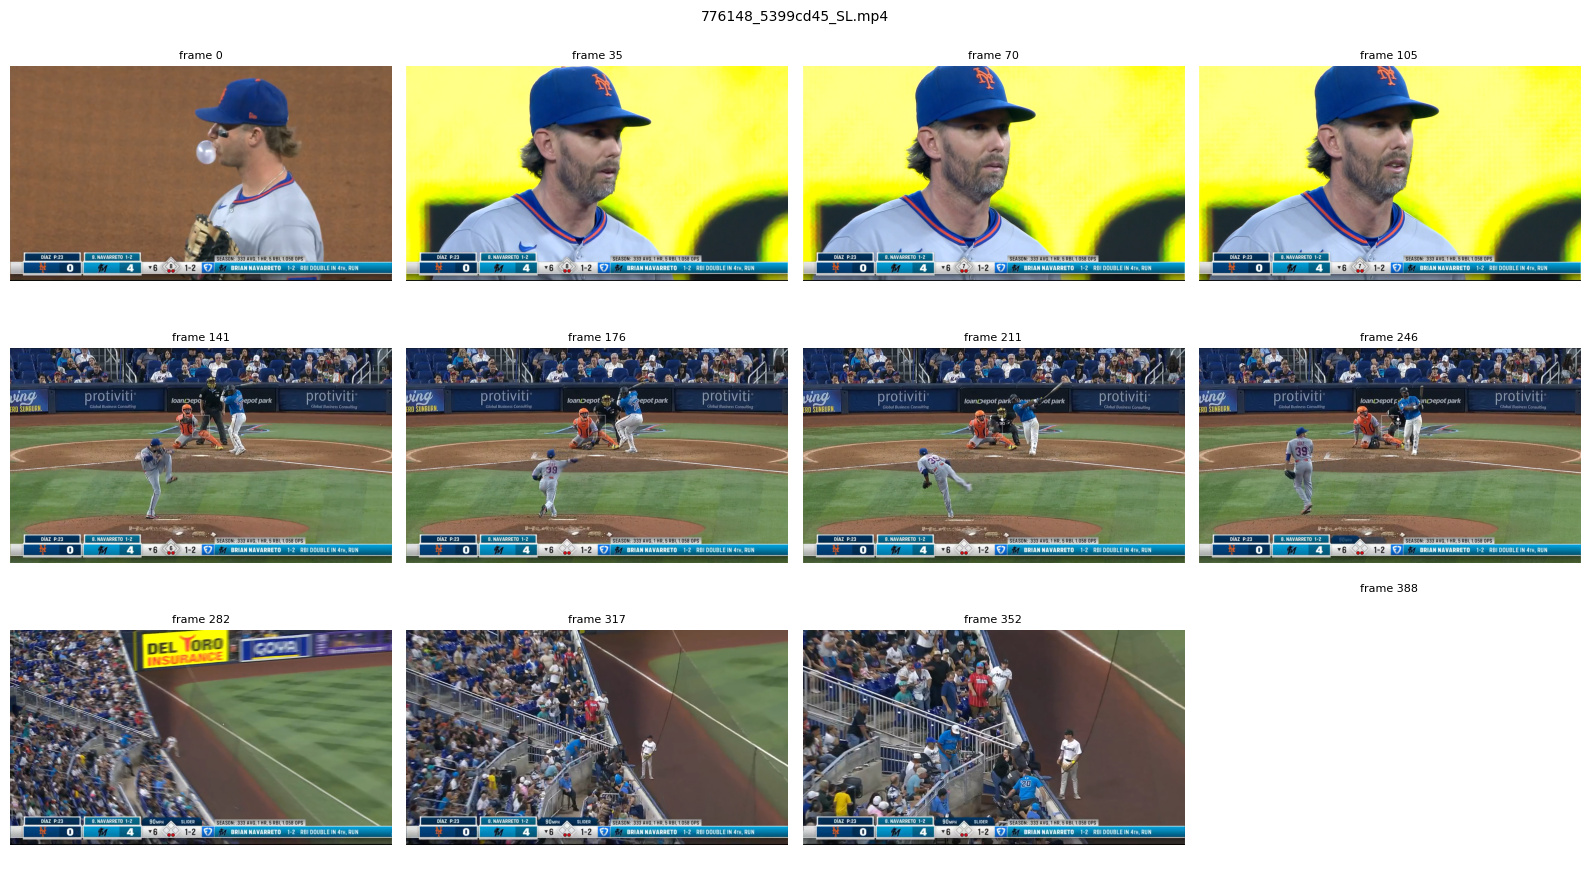

In [9]:
SAMPLE_VIDEO = sorted(DATA_DIR.glob("*.mp4"))[0]
print(f"Sampling from: {SAMPLE_VIDEO.name}")

cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# Evenly spaced frames across the video
sample_indices = np.linspace(0, total_frames - 1, 12, dtype=int)

fig, axes = plt.subplots(3, 4, figsize=(16, 9))
for ax, idx in zip(axes.flat, sample_indices):
    cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
    ret, frame = cap.read()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {idx}", fontsize=8)
    ax.axis("off")
cap.release()
plt.suptitle(SAMPLE_VIDEO.name, fontsize=10)
plt.tight_layout()
plt.show()


## 5. Background Subtraction — Ball Detection Attempt
MOG2 subtracts the static background (mound, grass, stands) and returns moving foreground blobs. The baseball should appear as a small bright blob.

In [10]:
SAMPLE_VIDEO = sorted(DATA_DIR.glob("*.mp4"))[0]

cap = cv2.VideoCapture(str(SAMPLE_VIDEO))
fgbg = cv2.createBackgroundSubtractorMOG2(history=30, varThreshold=50, detectShadows=False)

# Warm up the background model on the first 30 frames
for _ in range(30):
    ret, frame = cap.read()
    if ret:
        fgbg.apply(frame)

# Collect foreground masks for next 60 frames
masks, frames_rgb = [], []
for _ in range(60):
    ret, frame = cap.read()
    if not ret:
        break
    mask = fgbg.apply(frame)
    # Morphological cleanup: remove noise, fill small gaps
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    masks.append(mask)
    frames_rgb.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
cap.release()

print(f"Collected {len(masks)} frames")


Collected 60 frames


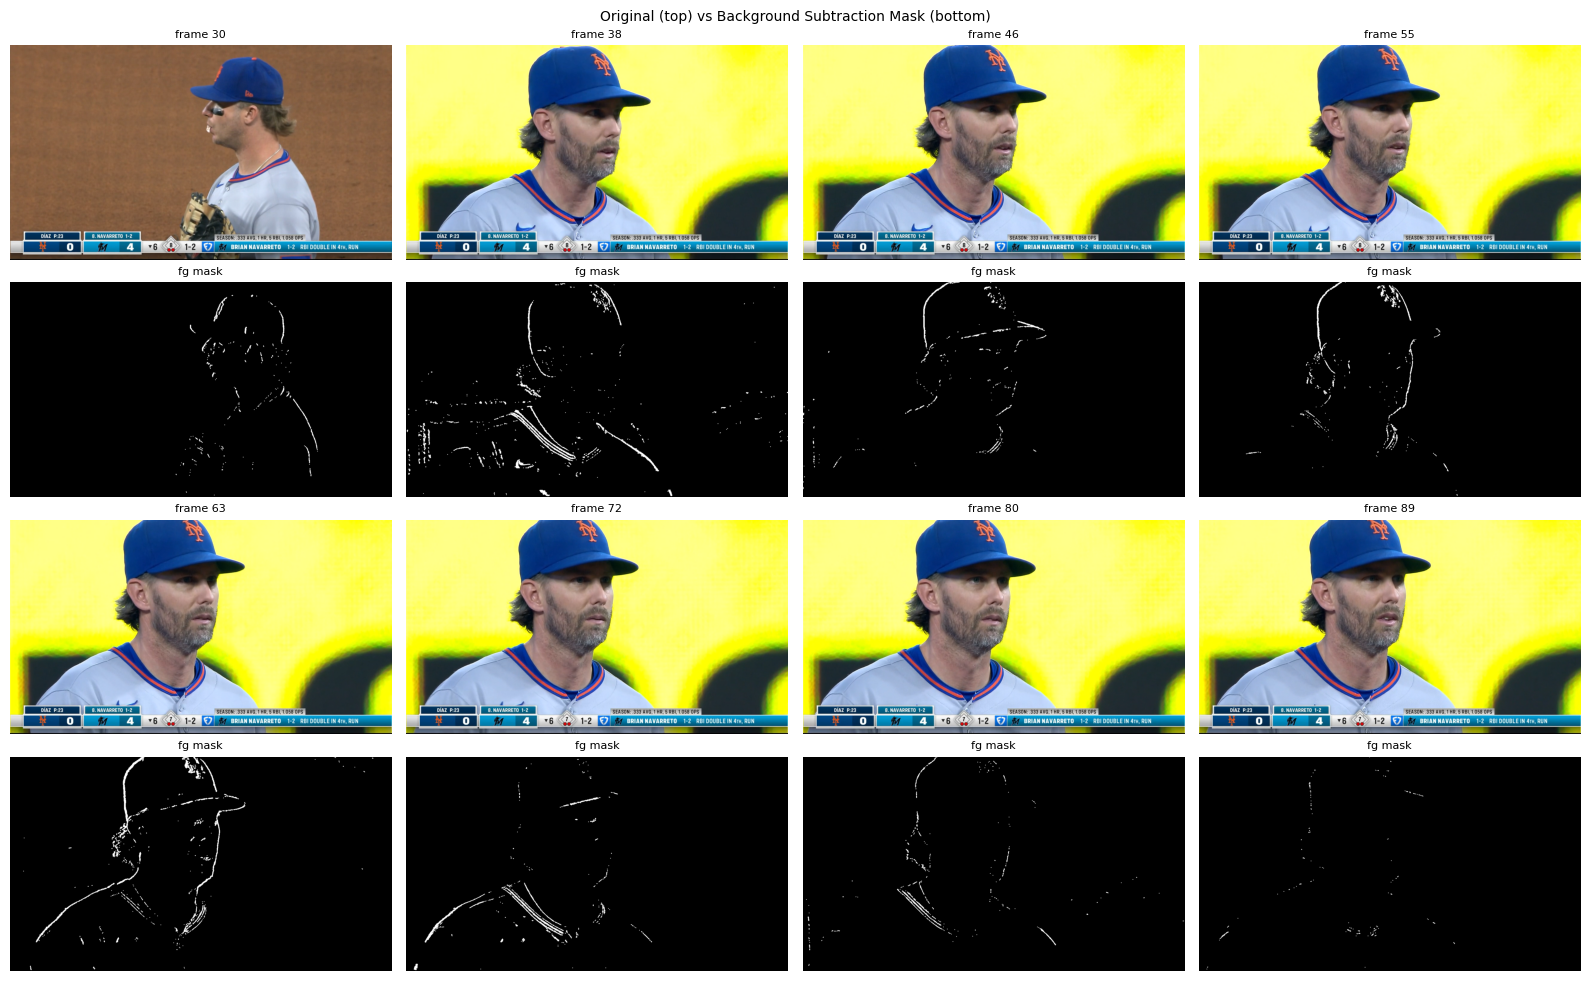

In [11]:
# Show a few frames with their foreground masks side-by-side
fig, axes = plt.subplots(4, 4, figsize=(16, 10))
sample_idx = np.linspace(0, len(masks)-1, 8, dtype=int)
for i, idx in enumerate(sample_idx):
    axes[i//4*2, i%4].imshow(frames_rgb[idx])
    axes[i//4*2, i%4].set_title(f"frame {30+idx}", fontsize=8)
    axes[i//4*2, i%4].axis("off")
    axes[i//4*2+1, i%4].imshow(masks[idx], cmap="gray")
    axes[i//4*2+1, i%4].set_title("fg mask", fontsize=8)
    axes[i//4*2+1, i%4].axis("off")
plt.suptitle("Original (top) vs Background Subtraction Mask (bottom)", fontsize=10)
plt.tight_layout()
plt.show()


In [12]:
# Find the blob most likely to be the baseball (small, round, fast-moving)
def find_ball_candidates(mask, min_area=5, max_area=400):
    """Return centroids of contours that could be a baseball."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    candidates = []
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if not (min_area < area < max_area):
            continue
        # Circularity check: 4π·area / perimeter²  (1.0 = perfect circle)
        perimeter = cv2.arcLength(cnt, True)
        if perimeter == 0:
            continue
        circularity = 4 * np.pi * area / (perimeter ** 2)
        if circularity < 0.3:  # ignore elongated blobs
            continue
        M = cv2.moments(cnt)
        if M["m00"] == 0:
            continue
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        candidates.append({"x": cx, "y": cy, "area": area, "circularity": round(circularity, 2)})
    return candidates

detections = [find_ball_candidates(m) for m in masks]
detected_count = sum(1 for d in detections if d)
print(f"Frames with at least one ball candidate: {detected_count}/{len(masks)}")


Frames with at least one ball candidate: 60/60


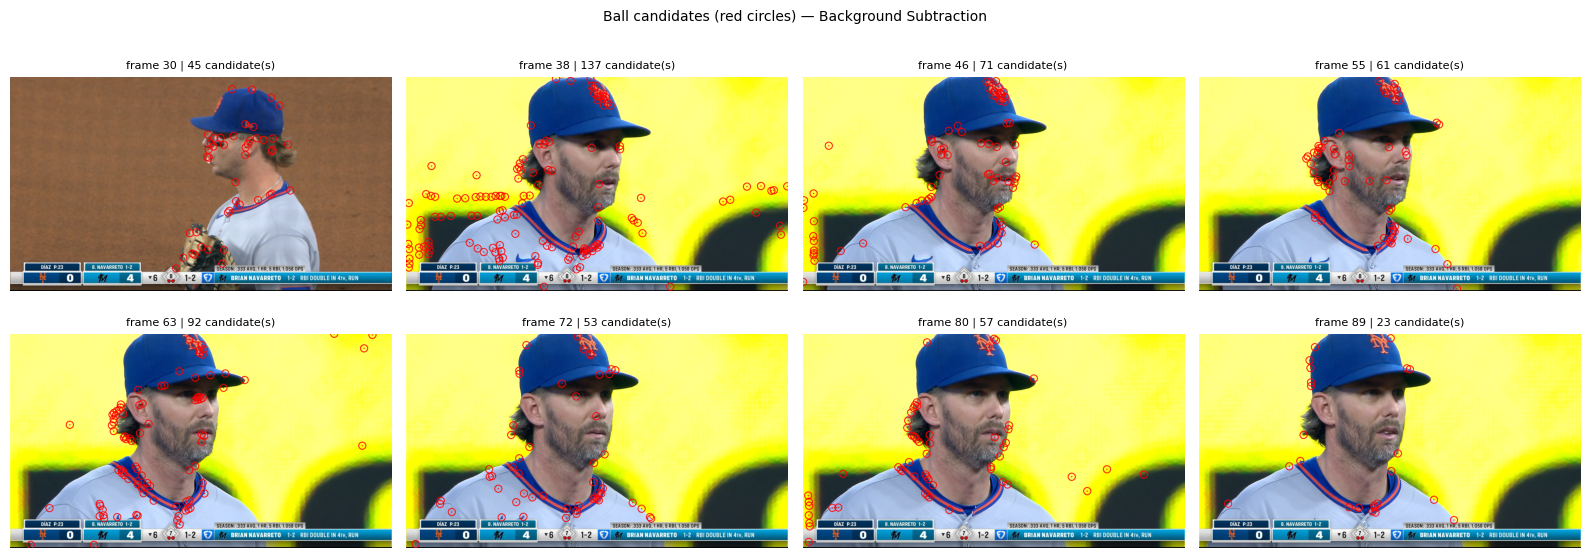

In [13]:
# Overlay detections on frames
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, idx in zip(axes.flat, np.linspace(0, len(masks)-1, 8, dtype=int)):
    vis = frames_rgb[idx].copy()
    for det in detections[idx]:
        cv2.circle(vis, (det["x"], det["y"]), 12, (255, 0, 0), 2)
        cv2.circle(vis, (det["x"], det["y"]), 2, (255, 0, 0), -1)
    ax.imshow(vis)
    ax.set_title(f"frame {30+idx} | {len(detections[idx])} candidate(s)", fontsize=8)
    ax.axis("off")
plt.suptitle("Ball candidates (red circles) — Background Subtraction", fontsize=10)
plt.tight_layout()
plt.show()
